Gym Member Activity Analysis Using Machine Learning Project Overview

The objective of this project is to predict the weekly workout frequency of gym members based on their physical characteristics, workout type, and experience level.

By applying machine learning algorithms, the project aims to develop a predictive model capable of estimating how often a person exercises each week using the available input data.

Such predictive models can be applied in fitness applications, recommendation systems, and gym member activity analysis to support personalized training plans and user engagement.

Dataset Description

The dataset includes the following features:

Age – Age of the gym member

Gender – Gender

Weight (kg) – Body weight in kilograms

Height (m) – Height in meters

Max_BPM – Maximum heart rate during workout

Avg_BPM – Average heart rate during workout

Resting_BPM – Resting heart rate

Session_Duration (hours) – Workout session duration

Calories_Burned – Number of calories burned

Fat_Percentage – Body fat percentage

Water_Intake (liters) – Daily water intake

Experience_Level – Training experience level

BMI – Body Mass Index

Workout_Type – Type of workout

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn import preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier



Loading the Dataset

In [ ]:
df = pd.read_csv("/content/gym_members_exercise_tracking.csv")

print("Podgląd danych:")
print(df.head())

Podgląd danych:
   Age  Gender  Weight (kg)  Height (m)  Max_BPM  Avg_BPM  Resting_BPM  \
0   56    Male         88.3        1.71      180      157           60   
1   46  Female         74.9        1.53      179      151           66   
2   32  Female         68.1        1.66      167      122           54   
3   25    Male         53.2        1.70      190      164           56   
4   38    Male         46.1        1.79      188      158           68   

   Session_Duration (hours)  Calories_Burned Workout_Type  Fat_Percentage  \
0                      1.69           1313.0         Yoga            12.6   
1                      1.30            883.0         HIIT            33.9   
2                      1.11            677.0       Cardio            33.4   
3                      0.59            532.0     Strength            28.8   
4                      0.64            556.0     Strength            29.2   

   Water_Intake (liters)  Workout_Frequency (days/week)  Experience_Level  \

*Data* Analysis


Statystyki danych:
              Age  Weight (kg)  Height (m)     Max_BPM     Avg_BPM  \
count  973.000000   973.000000   973.00000  973.000000  973.000000   
mean    38.683453    73.854676     1.72258  179.883864  143.766701   
std     12.180928    21.207500     0.12772   11.525686   14.345101   
min     18.000000    40.000000     1.50000  160.000000  120.000000   
25%     28.000000    58.100000     1.62000  170.000000  131.000000   
50%     40.000000    70.000000     1.71000  180.000000  143.000000   
75%     49.000000    86.000000     1.80000  190.000000  156.000000   
max     59.000000   129.900000     2.00000  199.000000  169.000000   

       Resting_BPM  Session_Duration (hours)  Calories_Burned  Fat_Percentage  \
count   973.000000                973.000000       973.000000      973.000000   
mean     62.223022                  1.256423       905.422405       24.976773   
std       7.327060                  0.343033       272.641516        6.259419   
min      50.000000       

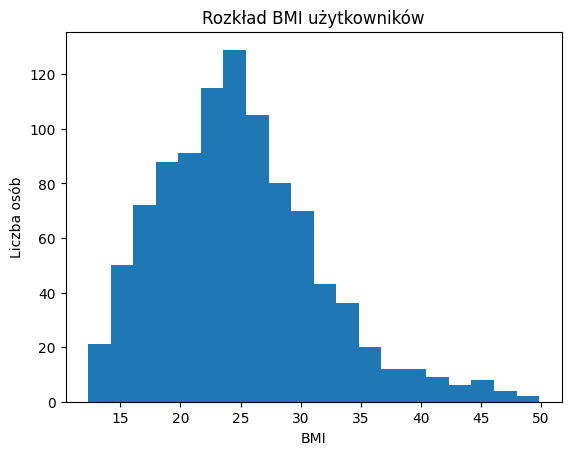

In [ ]:
print("\nStatystyki danych:")
print(df.describe())

# Histogram BMI
plt.figure()
plt.hist(df['BMI'], bins=20)
plt.title("Rozkład BMI użytkowników")
plt.xlabel("BMI")
plt.ylabel("Liczba osób")
plt.show()

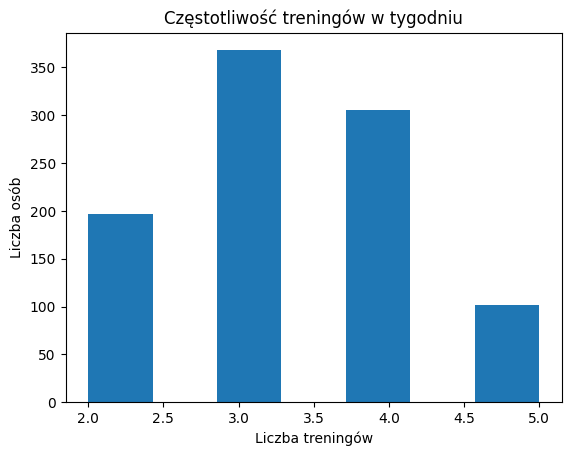

In [ ]:
# Histogram liczby treningów
plt.figure()
plt.hist(df['Workout_Frequency (days/week)'], bins=7)
plt.title("Częstotliwość treningów w tygodniu")
plt.xlabel("Liczba treningów")
plt.ylabel("Liczba osób")
plt.show()

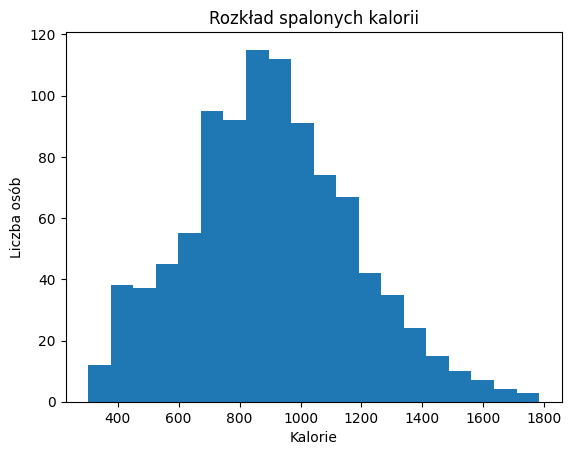

In [ ]:
# Histogram spalonych kalorii
plt.figure()
plt.hist(df['Calories_Burned'], bins=20)
plt.title("Rozkład spalonych kalorii")
plt.xlabel("Kalorie")
plt.ylabel("Liczba osób")
plt.show()



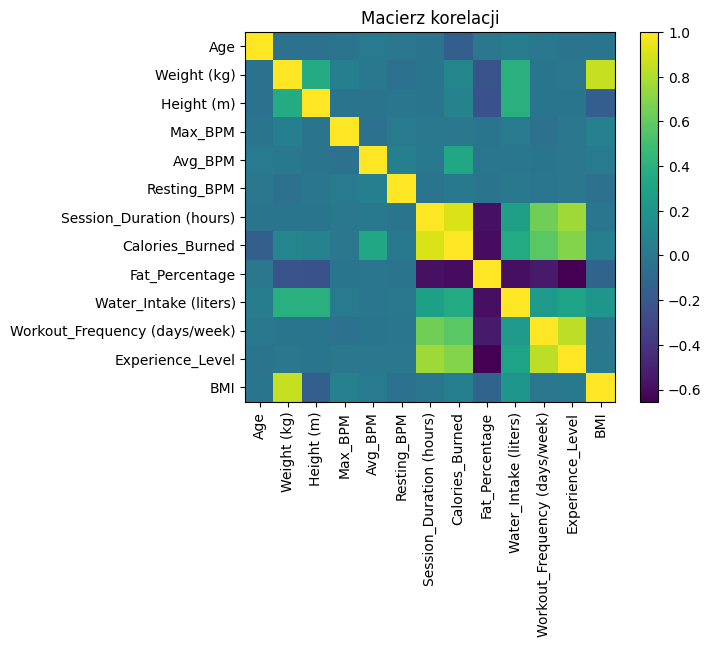

In [ ]:
# Macierz korelacji
plt.figure()

corr = df.corr(numeric_only=True)

plt.imshow(corr)
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Macierz korelacji")

plt.show()

Data Preprocessing

In [ ]:
le_gender = preprocessing.LabelEncoder()
df['Gender'] = le_gender.fit_transform(df['Gender'])

le_workout = preprocessing.LabelEncoder()
df['Workout_Type'] = le_workout.fit_transform(df['Workout_Type'])

Feature and Target Selection

In [ ]:
X = df[['Age','Gender','Weight (kg)','Height (m)','Max_BPM','Avg_BPM',
        'Resting_BPM','Session_Duration (hours)','Calories_Burned',
        'Fat_Percentage','Water_Intake (liters)','Experience_Level',
        'BMI','Workout_Type']]

y = df['Workout_Frequency (days/week)']

Train-Test Split


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.35,
    random_state=42
)

Machine Learning Models

In [ ]:
clfs = {
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Bagging": BaggingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}

Model Training and Evaluation

In [ ]:
results = {}

print("\n===== TRAIN / TEST RESULTS =====\n")

for name, clf in clfs.items():

    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro')
    recall = recall_score(y_test, y_pred, average='macro')

    f1 = (2 * precision * recall) / (precision + recall)

    print(name)
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("\n----------------------\n")

    results[name] = f1


===== TRAIN / TEST RESULTS =====

Decision Tree
Accuracy: 0.5219941348973607
Precision: 0.5181206975711121
Recall: 0.525914037516109

Confusion Matrix:
[[46 27  0  0]
 [35 60 28  0]
 [ 0 36 55 19]
 [ 0  0 18 17]]

Classification Report:
              precision    recall  f1-score   support

           2       0.57      0.63      0.60        73
           3       0.49      0.49      0.49       123
           4       0.54      0.50      0.52       110
           5       0.47      0.49      0.48        35

    accuracy                           0.52       341
   macro avg       0.52      0.53      0.52       341
weighted avg       0.52      0.52      0.52       341


----------------------

Random Forest
Accuracy: 0.5278592375366569
Precision: 0.5460968234333918
Recall: 0.5427882230254432

Confusion Matrix:
[[40 33  0  0]
 [28 61 34  0]
 [ 0 37 58 15]
 [ 0  0 14 21]]

Classification Report:
              precision    recall  f1-score   support

           2       0.59      0.55      0.57

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

AdaBoost
Accuracy: 0.4633431085043988
Precision: 0.2413138332255979
Recall: 0.5

Confusion Matrix:
[[  0  73   0   0]
 [  0 123   0   0]
 [  0  77   0  33]
 [  0   0   0  35]]

Classification Report:
              precision    recall  f1-score   support

           2       0.00      0.00      0.00        73
           3       0.45      1.00      0.62       123
           4       0.00      0.00      0.00       110
           5       0.51      1.00      0.68        35

    accuracy                           0.46       341
   macro avg       0.24      0.50      0.33       341
weighted avg       0.22      0.46      0.29       341


----------------------

Gradient Boosting
Accuracy: 0.4750733137829912
Precision: 0.48913441702572136
Recall: 0.4887812905437362

Confusion Matrix:
[[35 38  0  0]
 [34 51 38  0]
 [ 0 36 57 17]
 [ 0  0 16 19]]

Classification Report:
              precision    recall  f1-score   support

           2       0.51      0.48      0.49        73
           3       0.4

Cross Validation

In [ ]:
print("\n===== CROSS VALIDATION =====\n")

cv_results = {}

for name, clf in clfs.items():

    scores = cross_val_score(clf, X, y, cv=5)

    mean_score = scores.mean()

    cv_results[name] = mean_score

    print(name)
    print("CV scores:", scores)
    print("Mean:", mean_score)
    print()


===== CROSS VALIDATION =====

Decision Tree
CV scores: [0.51794872 0.51794872 0.49230769 0.47938144 0.47938144]
Mean: 0.4973936029606133

Random Forest
CV scores: [0.52820513 0.45128205 0.54358974 0.48453608 0.50515464]
Mean: 0.5025535289452815

Bagging
CV scores: [0.53333333 0.47179487 0.52820513 0.4742268  0.53092784]
Mean: 0.5076975945017181

AdaBoost
CV scores: [0.48205128 0.48205128 0.48205128 0.48453608 0.48453608]
Mean: 0.48304520222045993

Gradient Boosting
CV scores: [0.51282051 0.4974359  0.46153846 0.4742268  0.56185567]
Mean: 0.5015754692043352



Model Performance Comparison

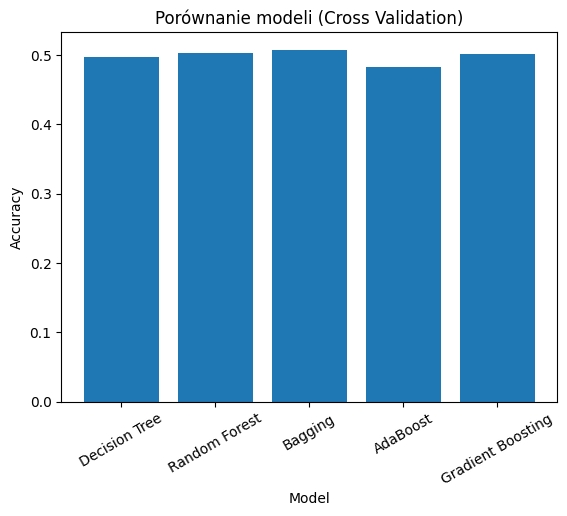

In [ ]:
plt.figure()

plt.bar(cv_results.keys(), cv_results.values())

plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Porównanie modeli (Cross Validation)")

plt.xticks(rotation=30)

plt.show()


Best Model Selection

In [ ]:
best_model_name = max(results, key=results.get)

print("\nNajlepszy model:", best_model_name)

best_model = clfs[best_model_name]


Najlepszy model: Random Forest


Final Model Training

In [ ]:
best_model.fit(X, y)

RandomForestClassifier()

Feature Importance

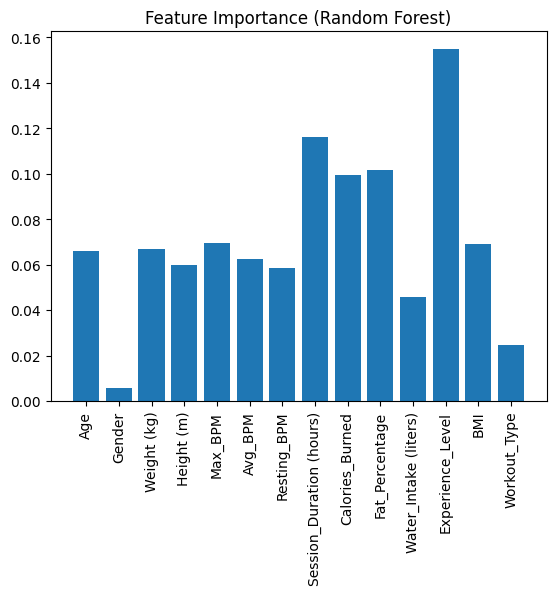

In [ ]:
if best_model_name == "Random Forest":

    importances = best_model.feature_importances_

    plt.figure()

    plt.bar(X.columns, importances)

    plt.xticks(rotation=90)

    plt.title("Feature Importance (Random Forest)")

    plt.show()

Prediction on New Data

In [ ]:
nowy_przypadek = [
    30,     # Age
    0,      # Gender
    70,     # Weight
    1.75,   # Height
    180,    # Max BPM
    150,    # Avg BPM
    70,     # Resting BPM
    1.2,    # Session Duration
    800,    # Calories
    25,     # Fat %
    2.5,    # Water intake
    3,      # Experience level
    24,     # BMI
    0       # Workout type
]

prediction = best_model.predict([nowy_przypadek])

print("\nPredykcja dla nowego przypadku:")
print(prediction)


Predykcja dla nowego przypadku:
[4]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Conclusions

The application of machine learning algorithms enabled accurate prediction of gym members' weekly workout frequency based on their physical characteristics and workout-related information.

By comparing multiple machine learning models, it was possible to identify the algorithm that achieved the best predictive performance for this dataset.

Ensemble learning methods, such as Random Forest and Gradient Boosting, outperformed simpler models due to their ability to combine multiple decision trees, resulting in improved prediction accuracy and better generalization.

Overall, this project demonstrates how machine learning techniques can be applied to analyze fitness data and support decision-making in fitness applications, recommendation systems, and user activity analysis.